### **Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu**

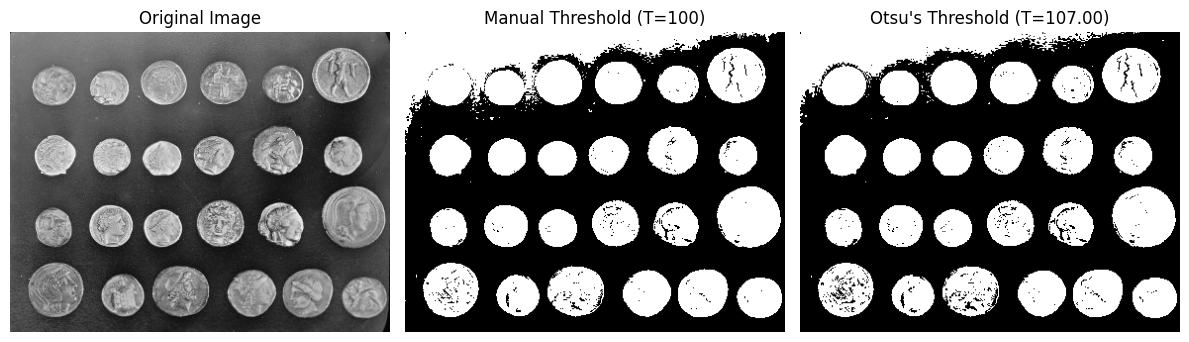

Nilai threshold Otsu yang ditemukan: 107


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap='gray')
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap='gray')
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

### **Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)**

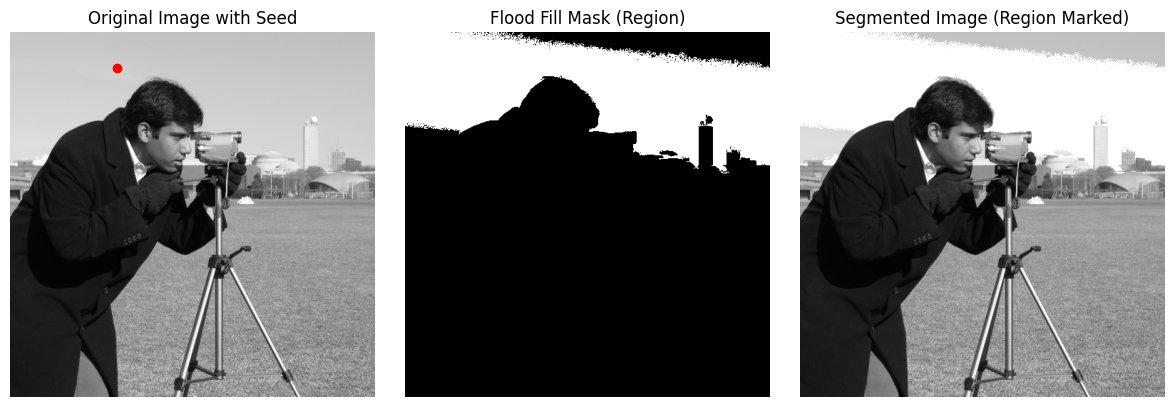

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misal, kita pilih titik di area langit (misal, koordinat y=50, x=150)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### **Praktikum 2. Segmentasi Menggunakan Region Growing (Mengubah titik seed dan Nilai tolerance)**

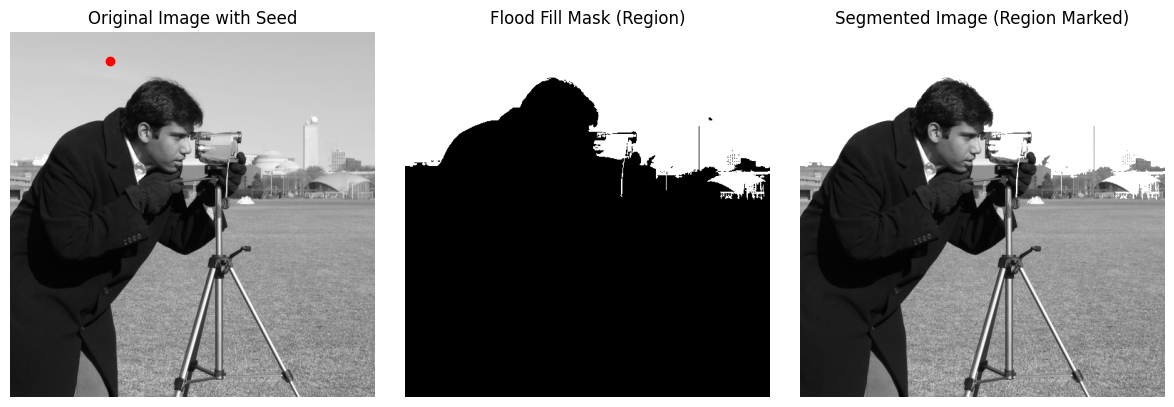

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misal, kita pilih titik di area langit (misal, koordinat y=50, x=150)
seed_point = (40, 140)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=50)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### **Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering**

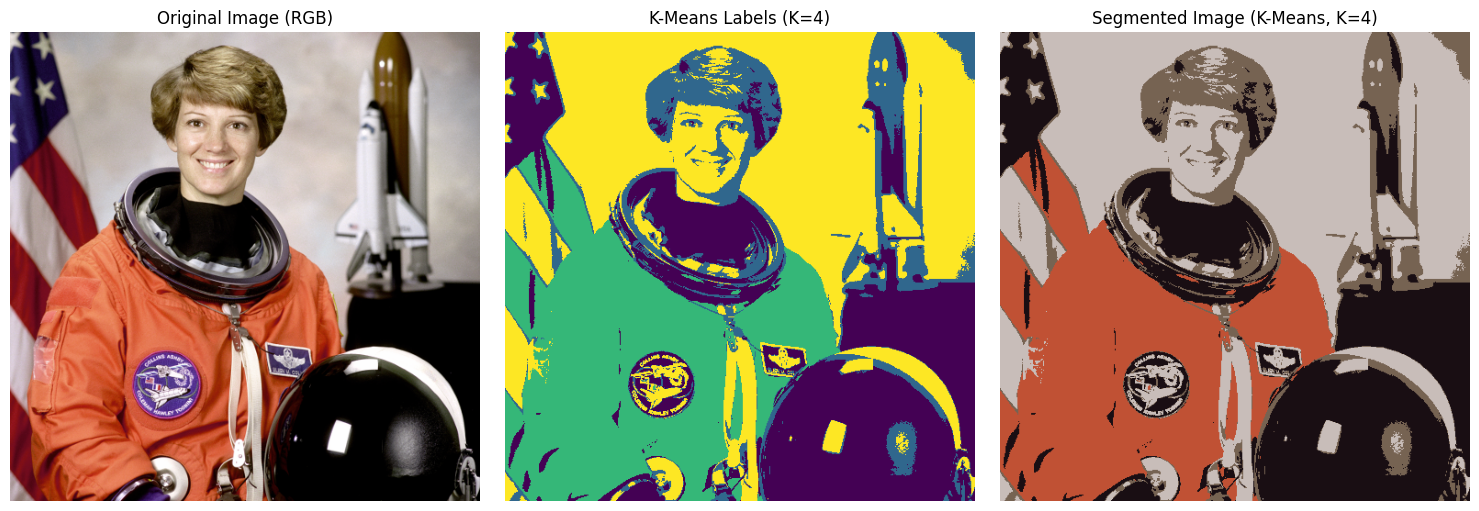

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2lab, lab2rgb
from sklearn.cluster import KMeans
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()
# Konversi ke float untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra menjadi array piksel [jumlah_piksel, jumlah_fitur]
# Fitur bisa RGB atau Lab. Ruang warna Lab seringkali lebih baik untuk persepsi warna.
# Konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
# Tentukan jumlah klaster (segmen) yang diinginkan, misal K=4
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)  # n_init=10 untuk kompatibilitas

# Hiding FutureWarnings terkait default value n_init
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra tersegmentasi (warnai setiap segmen dengan warna rata-rata klaster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    # Dapatkan piksel yang termasuk klaster k
    cluster_pixels = (pixel_labels == k)
    # Reshape cluster_pixels ke bentuk citra
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB untuk ditampilkan
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(15, 5))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Menampilkan label klaster
ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Menampilkan citra hasil segmentasi K-Means
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### **Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering(Mengubah Nilai K)**

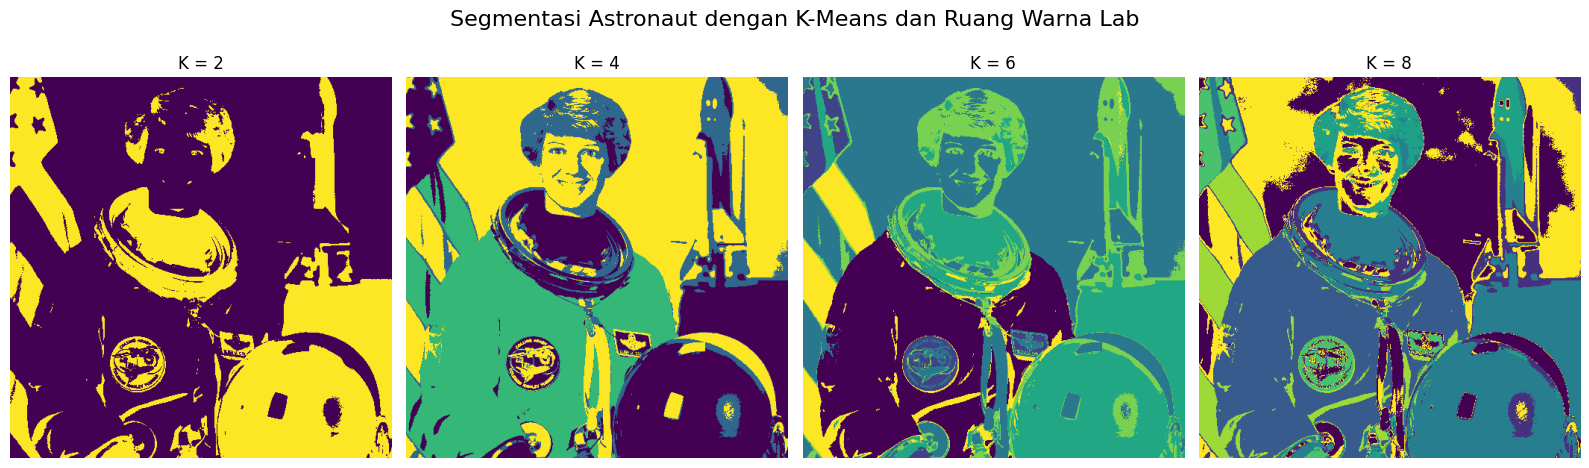

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2lab, lab2rgb
from sklearn.cluster import KMeans
import warnings

# Load image
image_astro = data.astronaut()
image_astro_float = image_astro.astype(float) / 255.0

# Convert to Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# Daftar jumlah klaster yang ingin diuji
cluster_list = [2, 4, 6, 8]

# Plot setup
fig, axes = plt.subplots(1, len(cluster_list), figsize=(16, 5))
axes = axes.ravel()

# Loop untuk setiap nilai K
for idx, k in enumerate(cluster_list):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pixel_labels = kmeans.fit_predict(pixel_features)

    segmented_labels = pixel_labels.reshape(rows, cols)

    axes[idx].imshow(segmented_labels, cmap='viridis')
    axes[idx].set_title(f'K = {k}')
    axes[idx].axis('off')

plt.suptitle('Segmentasi Astronaut dengan K-Means dan Ruang Warna Lab', fontsize=16)
plt.tight_layout()
plt.show()

### **Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed**

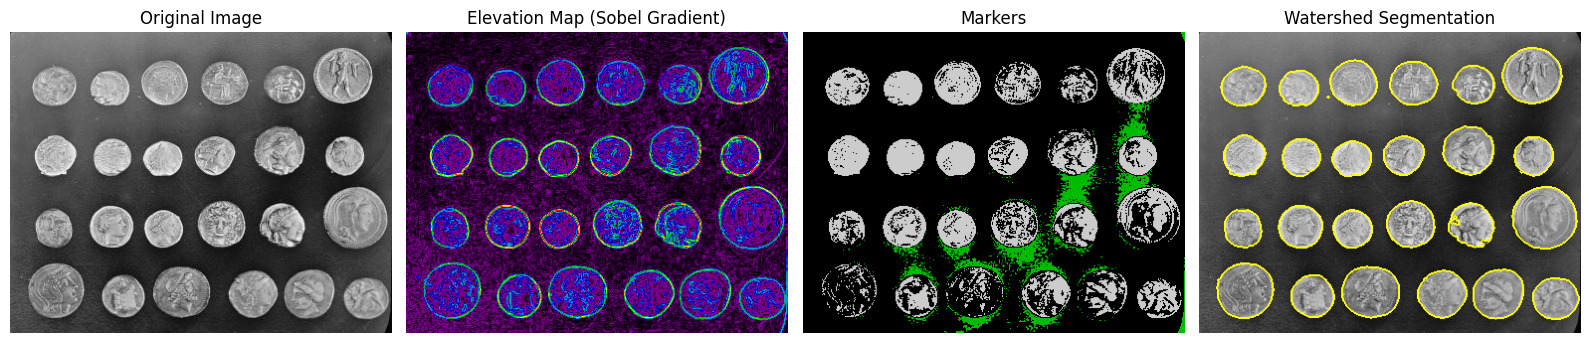

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker (penanda awal untuk setiap cekungan/objek)
# Menggunakan threshold sederhana
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1   # Marker untuk latar belakang
markers[image_coins > 150] = 2  # Marker untuk objek (koin)

# (Opsional) Marker canggih menggunakan local maxima - dinonaktifkan di sini
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi untuk visualisasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

### **Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed (Perbandingan antara Watershed dengan marker yang bagus dan Watershed dengan marker yang buruk)**

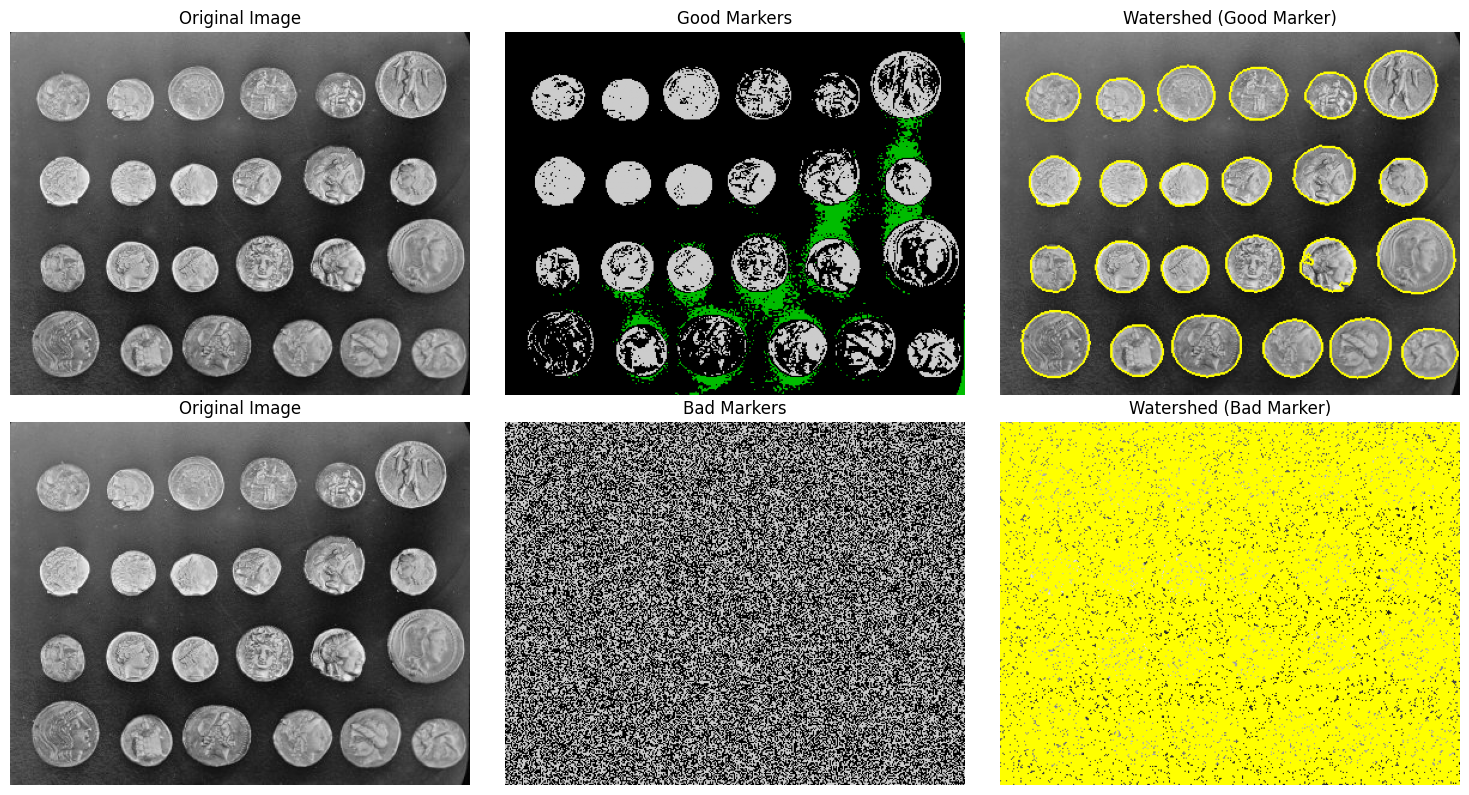

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation
from scipy import ndimage as ndi

# Load image
image_coins = data.coins()

# Elevation map (gradien)
elevation_map = filters.sobel(image_coins)

# ===== CASE 1: Marker Bagus =====
markers_good = np.zeros_like(image_coins)
markers_good[image_coins < 30] = 1  # background
markers_good[image_coins > 150] = 2  # objek koin

segmentation_good = segmentation.watershed(elevation_map, markers_good)
segmented_colored_good = segmentation.mark_boundaries(image_coins, segmentation_good)

# ===== CASE 2: Marker Buruk =====
np.random.seed(0)  # Biar hasil random tetap sama
markers_bad = np.random.randint(1, 3, size=image_coins.shape)

segmentation_bad = segmentation.watershed(elevation_map, markers_bad)
segmented_colored_bad = segmentation.mark_boundaries(image_coins, segmentation_bad)

# ===== Visualisasi =====
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Baris 1: Marker Bagus
axes[0, 0].imshow(image_coins, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(markers_good, cmap='nipy_spectral')
axes[0, 1].set_title('Good Markers')
axes[0, 1].axis('off')

axes[0, 2].imshow(segmented_colored_good)
axes[0, 2].set_title('Watershed (Good Marker)')
axes[0, 2].axis('off')

# Baris 2: Marker Buruk
axes[1, 0].imshow(image_coins, cmap='gray')
axes[1, 0].set_title('Original Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(markers_bad, cmap='nipy_spectral')
axes[1, 1].set_title('Bad Markers')
axes[1, 1].axis('off')

axes[1, 2].imshow(segmented_colored_bad)
axes[1, 2].set_title('Watershed (Bad Marker)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

### **Praktikum 5. Perbandingan Visual Hasil Segmentasi**

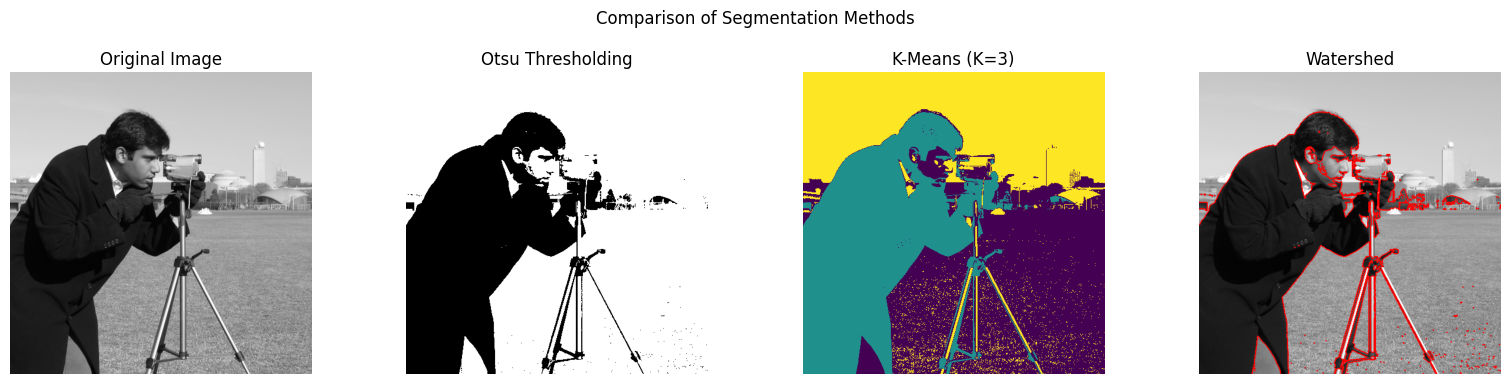

In [8]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan (misal: camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Lakukan beberapa metode segmentasi
# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
# Reshape untuk K-Means (1 fitur: intensitas)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

# Menangani warning selama KMeans fit
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')  # Gunakan cmap berbeda untuk label
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Gunakan mark_boundaries untuk Watershed agar lebih jelas
segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1, 0, 0))  # Batas merah
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make space for suptitle
plt.show()

### **Penugasan 3**

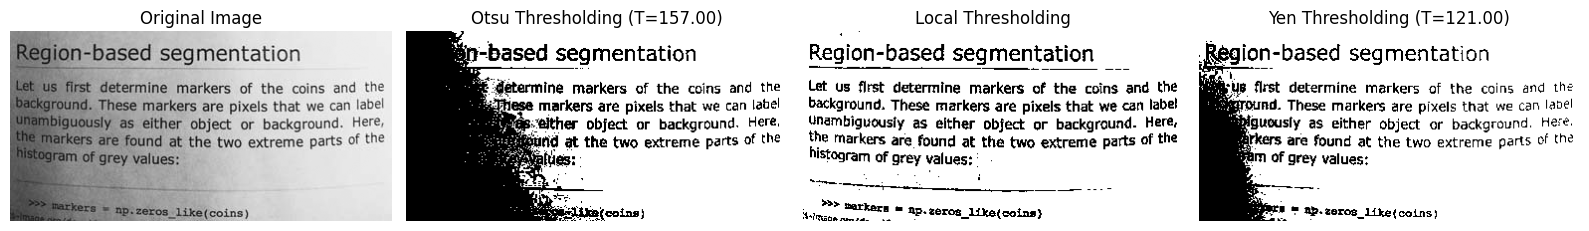

In [9]:
from skimage import data, filters, img_as_float
import matplotlib.pyplot as plt

# Memuat citra 'page' dari skimage
image_page = data.page()
image_page_float = img_as_float(image_page)

# Terapkan thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_page)
binary_otsu = image_page > thresh_otsu

# Terapkan thresholding lokal
thresh_local = filters.threshold_local(image_page, block_size=35, offset=10)
binary_local = image_page > thresh_local

# Terapkan thresholding Yen
thresh_yen = filters.threshold_yen(image_page)
binary_yen = image_page > thresh_yen

# Visualisasi hasil segmentasi
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
ax = axes.ravel()

# Menampilkan citra asli
ax[0].imshow(image_page, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Menampilkan hasil thresholding Otsu
ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title(f'Otsu Thresholding (T={thresh_otsu:.2f})')
ax[1].axis('off')

# Menampilkan hasil thresholding Lokal
ax[2].imshow(binary_local, cmap=plt.cm.gray)
ax[2].set_title('Local Thresholding')
ax[2].axis('off')

# Menampilkan hasil thresholding Yen
ax[3].imshow(binary_yen, cmap=plt.cm.gray)
ax[3].set_title(f'Yen Thresholding (T={thresh_yen:.2f})')
ax[3].axis('off')

plt.tight_layout()
plt.show()

### **Penugasan 3**

File yang tersedia di direktori saat ini:
['.config', 'Jeruk.jpg', 'sample_data']

Menggunakan file: Jeruk.jpg


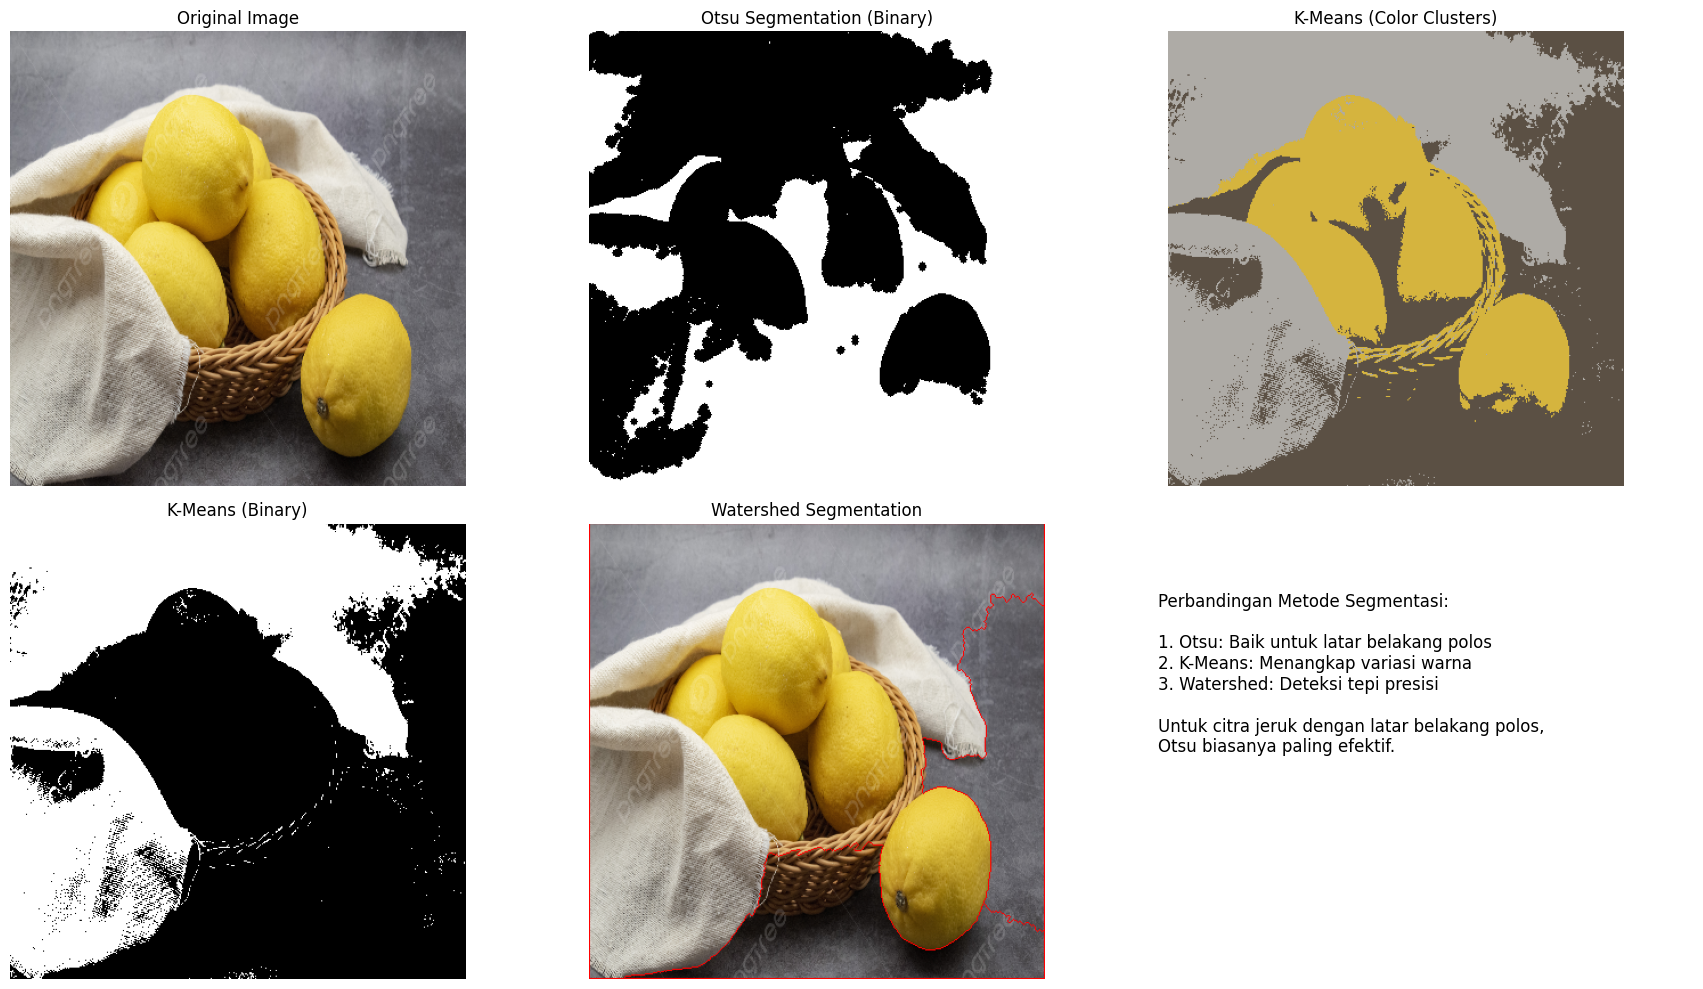


Analisis Hasil Segmentasi:
- Otsu: Metode paling sederhana dan cepat, cocok untuk objek dengan kontras tinggi
- K-Means: Menunjukkan variasi warna pada jeruk, membutuhkan penentuan jumlah cluster
- Watershed: Paling kompleks, berguna untuk deteksi tepi presisi tapi rentan over-segmentasi


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cluster import KMeans
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.morphology import closing, square, disk

def find_image_file(base_name):
    """Mencari file gambar dengan berbagai kemungkinan penulisan case"""
    possible_names = [
        base_name,
        base_name.lower(),
        base_name.upper(),
        base_name.capitalize()
    ]

    for name in possible_names:
        if os.path.exists(name):
            return name
    return None

def otsu_segmentation(img):
    """Segmentasi menggunakan metode Otsu"""
    # Konversi ke grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Thresholding Otsu
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Operasi morfologi untuk membersihkan hasil
    cleaned = closing(thresh, disk(3))

    return cleaned

def kmeans_segmentation(img, n_clusters=3):
    """Segmentasi menggunakan K-Means clustering"""
    # Reshape gambar ke array 2D piksel
    pixel_values = img.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)

    # Kriteria algoritma K-Means
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

    # Eksekusi K-Means
    _, labels, centers = cv2.kmeans(pixel_values, n_clusters, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    # Konversi kembali ke 8-bit
    centers = np.uint8(centers)

    # Rekonstruksi gambar hasil segmentasi
    segmented_image = centers[labels.flatten()]
    segmented_image = segmented_image.reshape(img.shape)

    # Buat versi biner dengan mengambil cluster dominan
    dominant_cluster = np.argmax(np.bincount(labels.flatten()))
    binary_segmented = np.uint8(labels.reshape(img.shape[:2]) == dominant_cluster) * 255

    return segmented_image, binary_segmented

def watershed_segmentation(img):
    """Segmentasi menggunakan algoritma Watershed"""
    # Konversi ke grayscale dan aplikasikan Gaussian blur
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Thresholding Otsu
    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Operasi morfologi untuk membersihkan noise
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    # Transformasi jarak
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)

    # Marker untuk watershed
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Labeling marker
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    # Aplikasi watershed
    markers = cv2.watershed(img, markers)

    # Visualisasi hasil
    img[markers == -1] = [255,0,0]  # Garis batas ditandai dengan merah

    return img

def plot_comparison(original, otsu, kmeans_color, kmeans_binary, watershed):
    """Visualisasi perbandingan hasil segmentasi"""
    plt.figure(figsize=(18, 10))

    # Plot original
    plt.subplot(2, 3, 1)
    plt.imshow(original)
    plt.title('Original Image')
    plt.axis('off')

    # Plot Otsu
    plt.subplot(2, 3, 2)
    plt.imshow(otsu, cmap='gray')
    plt.title('Otsu Segmentation (Binary)')
    plt.axis('off')

    # Plot K-Means Color
    plt.subplot(2, 3, 3)
    plt.imshow(kmeans_color)
    plt.title('K-Means (Color Clusters)')
    plt.axis('off')

    # Plot K-Means Binary
    plt.subplot(2, 3, 4)
    plt.imshow(kmeans_binary, cmap='gray')
    plt.title('K-Means (Binary)')
    plt.axis('off')

    # Plot Watershed
    plt.subplot(2, 3, 5)
    plt.imshow(watershed)
    plt.title('Watershed Segmentation')
    plt.axis('off')

    # Analisis perbandingan
    plt.subplot(2, 3, 6)
    plt.text(0.1, 0.5,
             "Perbandingan Metode Segmentasi:\n\n"
             "1. Otsu: Baik untuk latar belakang polos\n"
             "2. K-Means: Menangkap variasi warna\n"
             "3. Watershed: Deteksi tepi presisi\n\n"
             "Untuk citra jeruk dengan latar belakang polos,\n"
             "Otsu biasanya paling efektif.",
             fontsize=12, ha='left')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def main():
    # Daftar file yang tersedia
    print("File yang tersedia di direktori saat ini:")
    print(os.listdir())

    # Mencari file jeruk dengan berbagai variasi penulisan
    image_file = find_image_file("jeruk.jpg")

    if not image_file:
        print("\nError: File jeruk tidak ditemukan. File gambar yang tersedia:")
        print([f for f in os.listdir() if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        return

    print(f"\nMenggunakan file: {image_file}")

    try:
        # Load gambar
        img = cv2.imread(image_file)
        if img is None:
            raise ValueError("Gagal memuat gambar. File mungkin rusak atau bukan format gambar yang valid.")

        # Konversi warna
        original_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Preprocessing - resize untuk konsistensi
        processed_img = cv2.resize(original_img, (400, 400))

        # Aplikasi berbagai metode segmentasi
        otsu_result = otsu_segmentation(processed_img)
        kmeans_color, kmeans_binary = kmeans_segmentation(processed_img)
        watershed_result = watershed_segmentation(processed_img.copy())  # Gunakan copy untuk mempertahankan original

        # Tampilkan hasil perbandingan
        plot_comparison(processed_img, otsu_result, kmeans_color, kmeans_binary, watershed_result)

        # Analisis tambahan di console
        print("\nAnalisis Hasil Segmentasi:")
        print("- Otsu: Metode paling sederhana dan cepat, cocok untuk objek dengan kontras tinggi")
        print("- K-Means: Menunjukkan variasi warna pada jeruk, membutuhkan penentuan jumlah cluster")
        print("- Watershed: Paling kompleks, berguna untuk deteksi tepi presisi tapi rentan over-segmentasi")

    except Exception as e:
        print(f"Terjadi error: {str(e)}")

if __name__ == "__main__":
    main()